## Distribution Analysis

### Research Question

What is the statistical distribution of Bitcoin daily returns, and how does it compare with the normal distribution?

**Research Objectives**

By the end of this notebook, you will be able to:

Visualize the empirical distribution of Bitcoin returns.\
Compare empirical returns with the normal distribution.\
Understand skewness and kurtosis.\
Identify heavy tails and extreme observations.\
Explain why return distributions matter in quantitative finance.\
Why This Matters

Most financial models assume that returns follow a normal distribution. Before building predictive models or estimating risk, we must determine whether this assumption is supported by the data.

In [1]:
# Research Configuration

TICKER = "BTC-USD"

START_DATE = "2020-01-01"
END_DATE = "2026-06-20"

INTERVAL = "1d"

AUTO_ADJUST = True

REFRESH_CACHE = True

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from asset_pricing_lab.returns import arithmetic_returns
from crypto_alpha_lab.data.storage import load_prices

In [3]:
btc = load_prices(
    ticker=TICKER,
    start=START_DATE,
    end=END_DATE,
    interval=INTERVAL,
    auto_adjust=AUTO_ADJUST,
    refresh=REFRESH_CACHE,
)

simple_returns = arithmetic_returns(btc["Close"])

In [4]:
simple_returns.head()

Date
2020-01-02   -0.029819
2020-01-03    0.051452
2020-01-04    0.008955
2020-01-05    0.000089
2020-01-06    0.048291
Name: Close, dtype: float64

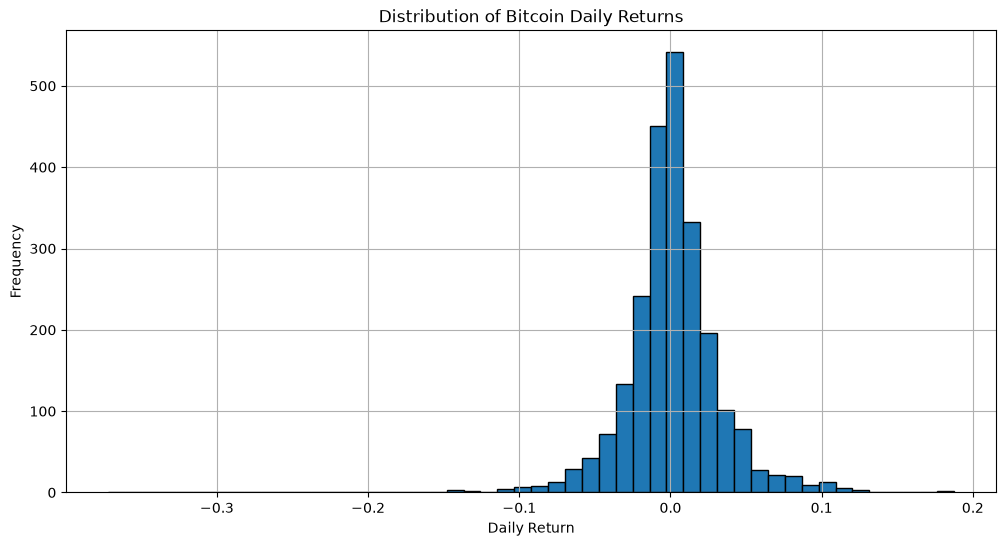

In [5]:
plt.figure(figsize=(12,6))

plt.hist(
    simple_returns,
    bins=50,
    edgecolor="black",
)

plt.title("Distribution of Bitcoin Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [6]:
print(f"Mean:      {simple_returns.mean():.6f}")
print(f"Median:    {simple_returns.median():.6f}")
print(f"Std Dev:   {simple_returns.std():.6f}")
print(f"Minimum:   {simple_returns.min():.6f}")
print(f"Maximum:   {simple_returns.max():.6f}")

Mean:      0.001429
Median:    0.000316
Std Dev:   0.031547
Minimum:   -0.371695
Maximum:   0.187465


### Histogram Interpretation

The histogram indicates that Bitcoin daily returns are centered close to zero, with a sample mean of **0.001429 (0.143%)** and a median of **0.000316 (0.032%)**. The mean exceeds the median, suggesting a slight positive asymmetry in the return distribution, although the difference is relatively small.

The sample standard deviation of **0.031547 (3.15%)** indicates substantial day-to-day variability, reflecting Bitcoin's high volatility relative to traditional financial assets. Most daily returns are concentrated around the center of the distribution, while larger price movements occur less frequently.

The observed return range extends from **−37.17%** to **+18.75%**, demonstrating that extreme market movements are present in the sample. Notably, the magnitude of the largest negative return exceeds that of the largest positive return, highlighting the potential for severe downside risk during periods of market stress.

Overall, the histogram appears approximately bell-shaped around its center but exhibits relatively heavy tails compared with a normal distribution. These findings suggest that while most trading days experience modest price changes, extreme gains and losses occur more frequently than would be expected under the normality assumption. This characteristic has important implications for portfolio risk management, volatility modeling, and the estimation of downside risk in cryptocurrency markets.

## Research Limitations

- Histogram appearance depends on the number of bins.
- Visual inspection alone cannot establish normality.
- Formal statistical measures are required.

## Next Notebook

In **Notebook 04**, we will study **Volatility Analysis**, including rolling volatility, volatility clustering, and the relationship between market risk and return variability.